# YEAR RUNS CONCAT :D

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
files_JAN = [
    '/home/vicentev/scratch/vicentev/Simulations_Runs_V2/Simulation_2007_JAN.nc'
]
#
files_FEB = [
    '/home/vicentev/scratch/vicentev/Simulations_Runs_V2/Simulation_2007_FEB.nc'
]
#
files_MAR = [
    '/home/vicentev/scratch/vicentev/Simulations_Runs_V2/Simulation_2007_MAR.nc'
]

files_APR = [
    '/home/vicentev/scratch/vicentev/Simulations_Runs_V2/Simulation_2007_APR.nc'
]

files_MAY = [
    '/home/vicentev/scratch/vicentev/Simulations_Runs_V2/Simulation_2007_MAY.nc'
]

files_JUN = [
    '/home/vicentev/scratch/vicentev/Simulations_Runs_V2/Simulation_2007_JUN.nc'
]

files_JUL = [
    '/home/vicentev/scratch/vicentev/Simulations_Runs_V2/Simulation_2007_JUL.nc'
]
files_AUG = [
    '/home/vicentev/scratch/vicentev/Simulations_Runs_V2/Simulation_2007_AUG.nc'
]

files_SEP = [
    '/home/vicentev/scratch/vicentev/Simulations_Runs_V2/Simulation_2007_SEP.nc'
]
files_OCT = [
    '/home/vicentev/scratch/vicentev/Simulations_Runs_V2/Simulation_2007_OCT.nc'
]

files_NOV = [
    '/home/vicentev/scratch/vicentev/Simulations_Runs_V2/Simulation_2007_NOV.nc'
]

files_DEC = [
    '/home/vicentev/scratch/vicentev/Simulations_Runs_V2/Simulation_2007_DEC.nc'
]

In [3]:
all_files = {
    'JAN': files_JAN, 'FEB': files_FEB, 'MAR': files_MAR, 'APR': files_APR,
    'MAY': files_MAY, 'JUN': files_JUN, 'JUL': files_JUL, 'AUG': files_AUG,
    'SEP': files_SEP, 'OCT': files_OCT, 'NOV': files_NOV, 'DEC': files_DEC
}

# Dictionary to store the final concatenated datasets
monthly_datasets = {}

for month, file_list in all_files.items():
    print(f"Processing {month}")
    #
    ds = xr.open_mfdataset(file_list, combine='nested', concat_dim='obs')
    monthly_datasets[month] = ds

Processing JAN
Processing FEB
Processing MAR
Processing APR
Processing MAY
Processing JUN
Processing JUL
Processing AUG
Processing SEP
Processing OCT
Processing NOV
Processing DEC


In [4]:
month_keys = [
    'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 
    'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC'
]
#
# minimum length across datasets (since simulations are not the same length)
dim_name = 'obs' 
min_obs = min(monthly_datasets[m].sizes[dim_name] for m in month_keys)
print(f"Trimming all datasets to {min_obs} time steps...")
#
trimmed_datasets = []
for m in month_keys:
    ds = monthly_datasets[m]
    #Trim to the common minimum length
    ds_trimmed = ds.isel({dim_name: slice(0, min_obs)})
    
    # Remove the 'obs' coordinate
    # just sees a simple dimension of length N
    if dim_name in ds_trimmed.coords:
        ds_trimmed = ds_trimmed.drop_vars(dim_name)
#        
    trimmed_datasets.append(ds_trimmed)
#
#Concatenate along 'trajectory'
full_year_ds = xr.concat(trimmed_datasets, dim='trajectory')
#New observation index from 0 to min_obs
full_year_ds = full_year_ds.assign_coords({dim_name: range(min_obs)})
#
print('New FULL dataset dimensions: ', full_year_ds.dims)

Trimming all datasets to 2920 time steps...
New FULL dataset dimensions:  FrozenMappingWarningOnValuesAccess({'trajectory': 35040, 'obs': 2920})


In [5]:
def proportions(data):
    # 1. Load data into memory
    status = data.status.values
    lat = data.lat.values
    lon = data.lon.values

    # 2. Create Validity Mask
    valid_mask = np.isfinite(status) & np.isfinite(lat) & np.isfinite(lon)

    # 3. Calculate Totals (Denominator)
    totals = valid_mask.sum(axis=0).astype(float)

    # 4. Helper to get raw counts efficiently
    def get_count(condition):
        return (condition & valid_mask).sum(axis=0)

    # 5. Calculate Raw Counts for all categories
    # We store these in a dictionary first
    raw_counts = {
        'initial':            get_count(status < 0),
        'colloidal_water':    get_count(status == 2),
        'marine_water':       get_count(status == 3),
        'sewage_water':       get_count(status == 1),
        'colloidal_sediment': get_count(status == 12),
        'marine_sediment':    get_count(status == 13),
        'sewage_sediment':    get_count(status == 11),
        'out_jdf':            get_count(status == 7),
        'out_js':             get_count(status == 8),
        'total_len':          totals
    }

    # 6. Calculate Percentages based on the Raw Counts
    # logic: (count / total) * 100
    percentages = {}
    for key, count_val in raw_counts.items():
        if key == 'total_len':
            percentages[key] = count_val  # Keep total as is
        else:
            percentages[key] = np.divide(
                count_val, 
                totals, 
                out=np.full_like(totals, np.nan), # Return NaN if divide by zero
                where=totals > 0
            ) * 100

    # 7. Define Column Order
    cols = [
        'initial', 'colloidal_water', 'marine_water', 'sewage_water',
        'colloidal_sediment', 'marine_sediment', 'sewage_sediment',
        'out_jdf', 'out_js', 'total_len'
    ]

    # 8. Create the two DataFrames
    df_proportions = pd.DataFrame(percentages, columns=cols)
    df_counts = pd.DataFrame(raw_counts, columns=cols)

    return df_proportions, df_counts

In [6]:
pp_proportions_V2, pp_counts_V2 = proportions(full_year_ds)

In [11]:
path_full = '/home/vicentev/scratch/vicentev/Simulations_Runs_V2/full_year_2007_V2.nc'
full_year_ds.to_netcdf(path_full ,mode='w')

In [8]:
data_V1 = xr.open_dataset('/home/vicentev/scratch/vicentev/long_term_simulation.nc').isel(obs = slice(None, 4380))

In [9]:
pp_proportions_V1, pp_counts_V1 = proportions(data_V1)

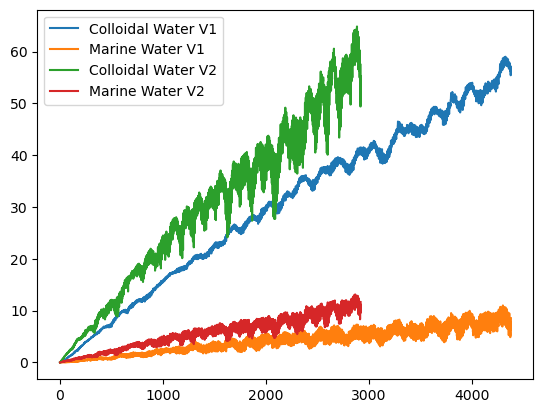

In [10]:
plt.plot(pp_proportions_V1['colloidal_water'], label = 'Colloidal Water V1')
plt.plot(pp_proportions_V1['marine_water'], label = 'Marine Water V1')
plt.plot(pp_proportions_V2['colloidal_water'], label = 'Colloidal Water V2')
plt.plot(pp_proportions_V2['marine_water'], label = 'Marine Water V2')
plt.legend()